# Function Setup - DO NOT TOUCH

In [10]:
# -----------------------------------------------------------------------
# Patrick Heng
# 2026-03-22
# Python script to calculate the financial feasibility of a chemical 
# plant. Paired with a Monte Carlo sensitivity analysis to capture risk
# of investment.
#
# WORK IN PROGRESS AS OF 04/17/26 !!!
# -----------------------------------------------------------------------

# Import numerical packages
import numpy as np
import scipy.stats as stats
from scipy import interpolate
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import matplotlib as mlp
import pandas as pd
try:
    import dataframe_image as dfi
except:
    # Package for easy conversion of dataframe tables to images
    !pip install dataframe_image
    import dataframe_image as dfi

# -----------------------------------------------------------------------
# For the following functions:
#      t = vector of increasing years over entire plant life
#      n = plant life span
#      k = ramp up period after construction is done
#      rate = interest/inflation rate
# -----------------------------------------------------------------------

# -----------------------------------------------------------------------
# P|F interest factor
def PF(rate,n): return np.power((1+rate),-np.array(range(n+1)))
# -----------------------------------------------------------------------
# Interest factor to account for inflation
def inflate(rate,n): return np.power((1+rate),np.array(range(n+1)))
# -----------------------------------------------------------------------
# Function to account for revenue/VCOP during plant startup period
def start_per(t, n, k): return  np.maximum(np.minimum((t-n)/k,1),0)
# -----------------------------------------------------------------------
# Function to generate MACRS depreciation table, returns table with GDS
# life classes [3,5,7,10,15,20] as columns, with rows spanning 21 years,
# starting from year 0 to year 20
def gen_MACRS_table():
    tab = np.zeros((22,8))
    tab[0:5,0] = [0,33.33,44.45,14.81,7.41] # 3-year
    tab[0:7,1] = [0,20,32,19.2,11.52,11.52,5.76] # 5-year
    tab[0:9,2] = [0,14.29,24.49,17.49,12.49,8.93,8.92,\
                  8.93,4.46] # 7-year
    tab[0:12,3] = [0,10,18,14.4,11.52,9.22,7.37,6.55,6.55,6.56,\
                   6.55,3.28] # 10-year
    tab[0:17,4] = [0,5,9.5,8.55,7.7,6.93,6.23,5.9,5.9,5.91,5.9,5.91,5.9,\
                   5.91,5.9,5.91,2.95] # 15-year
    tab[0:22,5] = [0,3.750,7.219,6.677,6.177,5.713,5.285,4.888,4.522,\
                   4.462,4.461,4.462,4.461,4.462,4.461,4.462,4.461,\
                   4.462,4.461,4.462,4.461,2.231] # 20-year
    return tab/100
    
# -----------------------------------------------------------------------
# MACRS class identifier for capital equipment
def get_MACRS_class(eq_list):
    
    tot_count = np.size(eq_list[:,0]) # Total count of equipment
    #classes = [3,5,7,10,15,20] # MACRS life classes

    # Loop over all equipment to find MACRS class, uses simple linear
    # search since data set is small
    for i in range(tot_count):
        lifespan = eq_list[i,-3]
        if lifespan == 0:   # No depreciation
            eq_list[i,-1] = 7
        elif lifespan <= 4: # MACRS 3-year
            eq_list[i,-1] = 0
        elif lifespan < 10: # MACRS 5-year
            eq_list[i,-1] = 1
        elif lifespan < 16: # MACRS 7-year
            eq_list[i,-1] = 2
        elif lifespan < 20: # MACRS 10-year
            eq_list[i,-1] = 3
        elif lifespan < 25: # MACRS 15-year
            eq_list[i,-1] = 4
        elif lifespan < 39: # MACRS 20-year
            eq_list[i,-1] = 5
        else:               # MACRS 39-year
            eq_list[i,-1] = 6
            
    return eq_list
# -----------------------------------------------------------------------
# Function to lookup sort out MTE equipment (pumps & compressors)
def get_MTE(eq_list):

    tot_count = np.size(eq_list[:,0]) # Total count of equipment
    
    #MTE_list = [] # List of material transport equipment
    #idx_list = [] # List of indices of non-MTE items

    for i in range(tot_count): # Search through array for pumps/comp
        if (eq_list[i,0].startswith('P-') or eq_list[i,0].startswith('C-')
            or eq_list[i,0].startswith('SC-')):
            #MTE_list.append(eq_list[i,:]) # Pump/comp found
            eq_list[i,-2] = 0
        else:
            #idx_list.append(i) # Skip
            eq_list[i,-2] = -1
    # List without MTE's
    #new_eq_list = eq_list[idx_list,:]
    
    return eq_list

# -----------------------------------------------------------------------
# Function to lookup MACRS depreciation based on equipment's lifespan
def MACRS(mclass,cost,MACRS_table):
    # k = equipment lifespan
    # mclass = MACRS life class 
    # cost = cost of equipment at year 0
    # MACRS_table = MACRS depreciation table
    if mclass == 7:
        val = 0
    if mclass == 6:
        val = np.ones(41)/40
        val[0] = 0
    else:
        val = MACRS_table[:,mclass]
    return val

# -----------------------------------------------------------------------
# Function to calculate MACRS depreciation over plant lifespan given 
# structured equipment list
def get_equipment(eq_list,**kwargs):

    # Get total analysis time (contruction + plant life)
    tot_time = N + const_time[0]
    # Create corresponding vector of years
    yr =  np.arange(tot_time) - const_time[0] + 1
    # Total count of equipment
    tot_count = np.size(eq_list[:,0]) 
    # Matrix of depreciation 'cash flows' rows = eq, cols = year
    eq_dep = np.zeros((tot_count,tot_time))
    # Matrix of purchase cash flows, rows = eq, cols = year
    equip_CF = np.zeros((tot_count,tot_time))
    # Matrix of salvage cash flows, rows = eq, cols = year
    salvage_CF = np.zeros((tot_count,tot_time))
    # Equipment book value, rows = eq, cols = year
    book_val = np.zeros((tot_count,tot_time))
    # MACRS life classes
    classes = [3,5,7,10,15,20,39,0]

    # Loop through all equipment
    for i in range(tot_count):
        mclass = eq_list[i,-1]   # MACRS class
        start_yr = eq_list[i,-2] # First year which eq. is bought
        lifespan = eq_list[i,-3] # Physical lifespan of eq
        cost = eq_list[i,2]      # Cost of eq
        # Index of when equipment is first bought
        start_idx = start_yr + const_time[0] - 1
        
        if lifespan != 0:

            # Number of replacements within plant's life
            num_replace = 1 + np.floor((tot_time-start_yr)/lifespan)
            # Get depreciation allowance percentages
            dep_allow = MACRS(mclass,cost,MACRS_table)
            # Number of depreciation years
            dep_life = classes[mclass] + 2
            # Calculate allowance over recovery period
            dep_period = cost*dep_allow[0:dep_life]
            # Book value over period
            bkv_period = cost - np.cumsum(dep_period)
            # Initialize depreciation 'cash flows'
            M = int(np.maximum(dep_life,lifespan)*(num_replace+1))
            dep = np.zeros(M)
            bkv = np.zeros(M)
            # Equipment purchase cash flows
            eq_CF = np.zeros(int(lifespan*(num_replace+1)))
            # Equipment salvage cash flows
            sal_CF = np.zeros(int(lifespan*(num_replace+1)))
           
            idx = start_idx + lifespan
            # Loop over plant's life, summing depreciation from replacements
            while idx <= tot_time:

                p = idx - const_time[0]
                inf1 = (1+gen_inf[0])**p # inflation interest factors
                inf2 = (1+gen_inf[0])**(p+lifespan)
                
                dep[idx:idx+dep_life] = dep_period*inf1 # Depreciation
                bkv[idx:idx+dep_life] = bkv_period*inf1 # Book value
                eq_CF[idx] = cost*inf1 # Equipment purchase
                sal_CF[idx+lifespan] = np.maximum(cost*sal_val, # Eq. sal.
                                                  bkv[idx+lifespan-1])*inf2 
                idx += lifespan
            # First depreciation lifecycle is unique since depreciation starts
            # at year 0 and production does not start before then
            idx = start_idx 
            k = const_time[0] - 1
            p = idx - const_time[0]
            inf1 = (1+gen_inf[0])**p # inflation interest factors
            inf2 = (1+gen_inf[0])**(p+lifespan)
            
            dep[k:dep_life+k] = dep_period*inf1 # Depreciation
            bkv[k:dep_life+k] = bkv_period*inf1 # Book value
            eq_CF[idx] = cost*inf1 # Equipment purchase
            sal_CF[idx+lifespan] = np.maximum(cost*sal_val, # Eq. sal.
                                              bkv[idx+lifespan-1])*inf2 
                
            # Cutoff depreciation schedule to correct length
            eq_dep[i,:] = dep[0:tot_time]
            equip_CF[i,:] = eq_CF[0:tot_time]
            salvage_CF[i,:] = sal_CF[0:tot_time]
            book_val[i,:] = bkv[0:tot_time]
            # 'Sell' the all equipment at the end of the planning horizon
            salvage_CF[i,-1] = np.maximum(cost*sal_val,bkv[tot_time-1])
        else:
            eq_dep[i,:] = 0
            equip_CF[i,:] = 0
            equip_CF[i,0] = cost
            salvage_CF[i,:] = 0
            book_val[i,start_idx:] = cost
    return eq_dep, equip_CF, salvage_CF, book_val

# -----------------------------------------------------------------------
# Function to calculate the discounted payback period (DPBP)
def get_DPBP(CDCF,**kwargs):
    # CDCF = cumulative discounted cashflow vector
    # Interpolate CDCF curve with cubic splines
    f = interpolate.CubicSpline(t,CDCF)
    # Root solve for a solution, guess lower half of lifespan
    sol = root_scalar(f,x0=N/2,x1=1,bracket=[1,N])
    # DPBP = root
    DPBP = sol.root
    return DPBP
# -----------------------------------------------------------------------
# Generate normal random variables such that ~95% data lies within
# upper and lower bounds
def gen_norm(x,size=1): return stats.norm.rvs(loc=x[0],
                                              scale=0.5*x[0]*x[1],
                                              size=size)
    
# -----------------------------------------------------------------------
# Generate Gumbel (skewed) random variables such that ~95% data 
# lies within upper and lower bounds
def gen_gum(x,size=1): return stats.gumbel_r.rvs(loc=x[0],\
                                scale=0.5*x[0]*x[1]*np.sqrt(6)/np.pi,\
                                size=size)

# -----------------------------------------------------------------------
# Get inflation from monthly value of log-cost indices, i.e.
#      log(IDX) = n*log(1+i) + log(IDX_0)
# Where IDX is the index at n, i is the effective interest, and IDX_0
# is the index at a reference time
def get_inf():
    # Read data for cost indices
    df = pd.read_csv('SP500_PPI_Adhesives.csv')
    # Cut off dates
    data = df.iloc[:,1:].to_numpy()
    # Number of compounding periods
    N = np.size(data[:,0])
    # Number of indices
    M = np.size(data[0,:])
    # Vector of compounding periods
    periods = np.arange(N)
    # Vector of rates
    rate = np.zeros(M)
    # Regress log index data to linear line
    for i in range(M):
        res = stats.linregress(periods,data[:,i])
        rate[i] = res.slope
    # Convert monthly compounding to annual
    rate = np.exp(rate)**12 - 1
    # Adjust rates for inflation
    rate[:-1] = (1+rate[:-1])/(1+rate[-1]) - 1
    
    return rate
    
# -----------------------------------------------------------------------
# Get MARR and WACC rate from debt/asset ratio, tax rate, loan rate, and 
# use CAPM linear model to estimate the cost of equity
def get_MARR(D_ratio,tax_rate,loan_rate,beta,rf_rate,risk_premium):
    # Get S&P 500 rate and inflation
    rate = get_inf()
    # Estimate equity using CAPM
    eq_prem = rate[0] - rf_rate
    equity_rate = rf_rate + beta*(eq_prem)
    # Estimate WACC
    WACC = D_ratio*loan_rate*(1-tax_rate) + (1-D_ratio)*equity_rate
    # Add risk premium to WACC to get uninflated MARR
    MARR_uninf = WACC + risk_premium
    # Adjust for inflation
    MARR = (1+MARR_uninf)*(1+rate[-1]) - 1
    # Summarize results in dataframe
    data={'Debt/Assets':D_ratio,'Equity/Assets':1-D_ratio, 
          'WACC':WACC,'MARR':MARR,'MARR (No Inf.)':MARR_uninf, 
          'Risk Premium':risk_premium,'Beta':beta, 
          'Cost of Equity':equity_rate, 'Loan Rate':loan_rate,
          'Risk-Free Rate': rf_rate,
          'S&P 500':rate[0],'Inflation':rate[-1]}
    df = pd.DataFrame([data])
    
    return MARR, WACC, df

# -----------------------------------------------------------------------
# Function to get utilities costs
def get_utilities(eq_list,utilities,**kwargs):
    # Utilities ID vector
    util_ID = eq_list[:,5]
    # Electricity for equipment [kW]
    elec = np.sum(eq_list[util_ID==1,4])
    # Water flow for equipment [kg/hr]
    wat_eq = np.sum(eq_list[util_ID==2,4])
    # Natural gas flow for equipment [m^3/hr]
    ng_eq = np.sum(eq_list[util_ID==3,4])
    # LP steam required [kW]
    LP_steam = np.sum(eq_list[util_ID==4,4])
    # HP steam required [kW]
    HP_steam = np.sum(eq_list[util_ID==5,4])
    # Total natural gas flow [m^3/hr]
    ng = ng_eq #+ 3600*(LP_steam + HP_steam)/(eta*nat_gas_energy_density)
    # Cooling tower evaporative losses, assume same losses for boiler
    E = 20.9/dh_2
    # Total water flow for process + steam [kg/hr]
    wat = E*(wat_eq + 3600*(LP_steam/dh_2 + HP_steam/dh_40))
    # Get utilities cost per unit
    util_cost = utilities.to_numpy()
    # Utility vector
    util_vec = np.array([elec,wat,ng,LP_steam,HP_steam])
    # Amount of utilities consumed
    util_consumed = op_hr*util_vec
    # Cost averaged over year [USD]
    util = util_consumed*util_cost[:-1,1]
    # Total cost averaged over year [USD]
    util_cost = np.sum(util)
    # Input utilities consumption into dataframe
    utilities['Units Bought [*]'] = [*util_consumed,0]
    # Utilities costs
    utilities['Cost [USD]'] = [*util,util_cost]
    # Utilities cash flows
    util_CF = util_cost*start_per(t,0,ramp_time) \
              *(1+util_inf[0])**t

    return utilities, util_CF
    
# -----------------------------------------------------------------------
# Function to get labor cash flows
def get_labor(labor,**kwargs):
    # Vector to determine if the staff is operational (variable cost)
    op_lab = labor['Operational Staff [0/1]'].to_numpy()[:-1]
    # Labor costs at full production
    lab_cost = labor['Total Cost [USD/Year]'].to_numpy()[:-1]
    # Labor cash flows
    fix_lab_cf = np.sum(op_lab*lab_cost)*start_per(t,0,1e-15)\
                        *(1+lab_inf[0])**t
    var_lab_cf = np.sum((1-op_lab)*lab_cost)*start_per(t,0,ramp_time)\
                        *(1+lab_inf[0])**t

    return fix_lab_cf, var_lab_cf
# -----------------------------------------------------------------------
# Function to get raw material cash flows
def get_raw_mat(raw_mat,**kwargs):
    # Convert raw material dataframe to numpy array
    raw_mat_np = raw_mat.to_numpy()
    # Get cash flows, accounting for start up period
    raw_mat_CF = np.dot(raw_mat_np[:,1],raw_mat_np[:,2]) \
                    *start_per(t, 0, ramp_time)*(1+raw_inf[0])**t
    return raw_mat_CF
# -----------------------------------------------------------------------
# Function to get O&M cash flows
def get_OM(equip,**kwargs): 
    equip_np = equip.to_numpy()
    OM_CF = np.sum(equip_np[:,3],axis=0)*start_per(t,0,ramp_time)\
                    *(1+lab_inf[0])**t
    return OM_CF
# -----------------------------------------------------------------------
# Function to get revenue cash flows
def get_revenue(sales,**kwargs):
    sales_np = sales.to_numpy()
    avg_price = np.mean(sales_np[:,1:2],axis=1)
    rev = avg_price*sales_np[:,-1]
    dc_period = discount + (1-discount)*start_per(t,0,N)
    rev_CF = np.tensordot(rev,start_per(t,0,ramp_time)*dc_period
                              *(1+prod_inf[0])**t,axes=0)
    return rev_CF
# -----------------------------------------------------------------------
# Function to calculate cost of compliance: permits, inspections, regs
def get_safety(safety,**kwargs):

    # Get total analysis time (contruction + plant life)
    tot_time = N + const_time[0]
    # Total count of permits
    tot_count = np.size(safety[:,0]) 
    # Matrix of purchase cash flows, rows = permit, cols = year
    safety_CF = np.zeros((tot_count,tot_time))

    # Loop through all equipment
    for i in range(tot_count):
        start_yr = safety[i,-1] # First year which eq. is bought
        lifespan = safety[i,-2] # Physical lifespan of eq
        cost = safety[i,1]*safety[i,2]      # Cost of eq
        # Index of when equipment is first bought
        start_idx = start_yr + const_time[0] - 1
        if lifespan != 0:
            idx = start_idx
            # Loop over plant's life
            while idx < tot_time:
                safety_CF[i,idx] = cost # Permit purchase 
                idx += lifespan
        # Infinite life         
        else:
            safety_CF[i,:] = 0
            safety_CF[i,start_idx] = cost
    return safety_CF
    
# -----------------------------------------------------------------------
# Function to calculate cash flows for turnaround budget
def get_turnaround(CAP0,**kwargs):
    # Total time horizon
    tot_time = N + const_time[0]
    # Start index of year 0
    idx = const_time[0] - 1 + turn_time
    # Turnaround cash flows
    M = int((np.ceil(N/turn_time)+1)*turn_time)
    turnaround_CF = np.zeros(M)
    # Loop through plant life
    while idx < tot_time:
        turnaround_CF[idx] = turn_frac[0]*CAP0
        idx += turn_time
    
    return turnaround_CF[0:tot_time]

# -----------------------------------------------------------------------
# Function to get loan payments (monthly or annual)
def get_loan(D_ratio,loan_rate,CAP0,monthly=True,**kwargs):

    # Total number of years for loan
    tot_time = N + const_time[0]

    # Check if a monthly or annual payment schedule is desired
    if monthly == True:
        i_m = (1+loan_rate)**(1/12) - 1
        periods = int(tot_time*12)
    else:
        i_m = loan_rate
        periods = tot_time
        
    # Initial principle
    loan = CAP0*D_ratio
    # A|P factor
    if loan_rate != 0:
        AP = (1-(1+i_m)**-periods)/i_m
    else:
        AP = 1
    # Payment per period
    pmt = loan/AP

    # Matrix of payment information
    monthly_pmt = np.zeros((7,periods+1))
    # Vector of periods
    monthly_pmt[0,:] = np.arange(periods+1)
    # Vector of payments
    monthly_pmt[1,1:] = pmt
    # Initial principle Balance
    monthly_pmt[6,0] = loan
    # Loop through all periods
    for i in range(1,periods+1):
        # Previous principle balance
        principle = monthly_pmt[6,i-1]
        # Interest payment
        ipmt = principle*i_m
        # Principle payment
        ppmt = pmt - ipmt
        # Store in payment matrix
        monthly_pmt[2,i] = ppmt
        monthly_pmt[3,i] = ipmt
        monthly_pmt[6,i] = principle - ppmt
    # Cumulative principle payment
    monthly_pmt[4,:] = np.cumsum(monthly_pmt[2,:])
    # Cumulative interest payment
    monthly_pmt[5,:] = np.cumsum(monthly_pmt[3,:])
    # Report results in a dataframe 
    pmt_df = pd.DataFrame({'Period':monthly_pmt[0,:],
                           'Payment [USD]':monthly_pmt[1,:],
                           'Principle Payment [USD]':monthly_pmt[2,:],
                           'Interest Payment [USD]':monthly_pmt[3,:],
                           'Cumulative Principle Payment [USD]':
                           monthly_pmt[4,:],
                           'Cumulative Interest Payment [USD]':
                           monthly_pmt[5,:],
                           'Principle Balance [USD]':monthly_pmt[6,:]})

    # Return interest payments and payment dataframe
    return monthly_pmt[3,1:], pmt_df
# -----------------------------------------------------------------------
# Function to read input Excel file
def get_all_CF(file_name,**params):
    
    # Read equipment list from exported Excel file 
    equip = pd.read_excel(file_name,sheet_name='Equipment')
    prop = pd.read_excel(file_name,sheet_name='Property')
    piping = pd.read_excel(file_name,sheet_name='Piping')
    controls = pd.read_excel(file_name,sheet_name='Controls')
    raw_mat = pd.read_excel(file_name,sheet_name='Raw Materials')
    sales = pd.read_excel(file_name,sheet_name='Sales')
    labor = pd.read_excel(file_name,sheet_name='Labor')
    utilities = pd.read_excel(file_name,sheet_name='Utilities')
    safety = pd.read_excel(file_name,sheet_name='Safety+Reg')
    
    # Delete all columns which are not required
    equip = equip[equip.columns[:7]]
    prop = prop[prop.columns[:6]]
    piping = piping[piping.columns[:5]]
    controls = controls[controls.columns[:6]]
    raw_mat = raw_mat[raw_mat.columns[:4]]
    sales = sales[sales.columns[:4]]
    #labor = labor[labor.columns[:2]]
    utilities = utilities[utilities.columns[:4]]
    safety = safety[safety.columns[:5]]
    
    # Add columns with appropriate descriptions
    equip['Start Year'] = 0
    equip['MACRS Class'] = 0
    
    # Convert dataframe to Numpy array
    eq_list = equip.to_numpy()
    
    # Get purchase year of equipment
    eq_list = get_MTE(eq_list)
    # Get MACRS class of equipment
    eq_list = get_MACRS_class(eq_list)
    # Update quipment list with calculated values
    equip['Start Year'] = eq_list[:,-2]
    equip['MACRS Class'] = eq_list[:,-1]
    
    # Add purchase year and MACRS class to dataframe
    #prop['Start Year'] = 0
    prop['MACRS Class'] = 0
    # Convert dataframe to Numpy array
    prop_list = prop.to_numpy()
    # Get MACRS class 
    prop_list = get_MACRS_class(prop_list)
    # Update dataframe with MACRS class
    prop['MACRS Class'] = prop_list[:,-1]
    
    # Add purchase year and MACRS class to dataframe
    controls['Start Year'] = 0
    controls['MACRS Class'] = 0
    # Convert dataframe to Numpy array
    controls_list = controls.to_numpy()
    # Get MACRS class 
    controls_list = get_MACRS_class(controls_list)
    # Update dataframe with MACRS class
    controls['MACRS Class'] = controls_list[:,-1]
    
    # Add purchase year and MACRS class to dataframe
    piping['Start Year'] = 0
    piping['MACRS Class'] = 0
    # Convert dataframe to Numpy array
    piping_list = piping.to_numpy()
    # Get MACRS class 
    piping_list = get_MACRS_class(piping_list)
    # Update dataframe with MACRS class
    piping['MACRS Class'] = piping_list[:,-1]
    
    # Convert dataframe to Numpy array
    safety_list = safety.to_numpy()

    names = ['equip','prop','piping','controls','raw_mat','sales',
             'utilities','safety','labor','eq_list','prop_list',
             'controls_list','piping_list','safety_list']

    # Initialize dictionary
    lists = {}
    # Loop through all key-value arguements
    for i in names:
        lists[i] = locals()[i]
        
    # Return input information dictionary
    return lists
    
# -----------------------------------------------------------------------
# Function to get all cash flows
def calc_all_CF(input_lists,util_params,params,MC=False,MC_params={}):

    # Unpack lists for input Excel data
    for k, v in input_lists.items():
        locals()[k] = v
        
    for k, v in params.items():
        locals()[k] = v

    for k, v in MC_params.items():
        locals()[k] = v
        
    # Check if Monte Carlo trial is being performed
    if MC == False:
        MC_params = {}
        MC_params['MC_work_cap'] = 1
        MC_params['MC_flat_tax_rate'] = 1 
        MC_params['MC_sales_tax_rate'] = 1   
        MC_params['MC_turn'] = 1
        MC_params['MC_EQ'] = 1
        MC_params['MC_PROP'] = 1
        MC_params['MC_PIPING'] = 1
        MC_params['MC_CONTROLS'] = 1
        
        MC_params['MC_OM'] = 1
        MC_params['MC_LAB'] = 1
        MC_params['MC_UTIL'] = 1
        MC_params['MC_UTIL_2'] = 1
        MC_params['MC_RAW'] = 1
        MC_params['MC_REV'] = 1

    # -------------------------------------------------------------------
    # --- CALCULATE CASH FLOWS ------------------------------------------
    # -------------------------------------------------------------------
    # Get equipment depreciation, cash flows, salvage, book value
    eq_dep, eq_CF, eq_sal_CF, eq_book_val = get_equipment(eq_list,**params)
    eq_dep *= MC_params['MC_EQ']
    eq_CF *= MC_params['MC_EQ']
    eq_sal_CF *= MC_params['MC_EQ']
    eq_book_val *= MC_params['MC_EQ']
    
    # Property CF
    prop_dep, prop_CF, prop_sal_CF, prop_book_val = \
                                            get_equipment(prop_list,**params)
    prop_dep *= MC_params['MC_PROP']
    prop_CF *= MC_params['MC_PROP']
    prop_sal_CF *= MC_params['MC_PROP']
    prop_book_val *= MC_params['MC_PROP']
    
    # Piping CF
    piping_dep, piping_CF, piping_sal_CF, piping_book_val = \
                                        get_equipment(piping_list,**params)
    piping_dep *= MC_params['MC_PIPING']
    piping_CF *= MC_params['MC_PIPING']
    piping_sal_CF *= MC_params['MC_PIPING']
    piping_book_val *= MC_params['MC_PIPING']
    
    # Get controls depreciation, cash flows, salvage, book value
    controls_dep, controls_CF, controls_sal_CF, controls_book_val = \
                                    get_equipment(controls_list,**params)
    controls_dep *= MC_params['MC_CONTROLS']
    controls_CF *= MC_params['MC_CONTROLS']
    controls_sal_CF *= MC_params['MC_CONTROLS']
    controls_book_val *= MC_params['MC_CONTROLS']
    
    # O&M CF
    OM_CF = get_OM(equip,**params) \
            + np.sum(prop['Annual Costs [USD/Year]'])*MC_params['MC_OM']
    # Raw materials CF
    raw_mat_CF = get_raw_mat(raw_mat,**params)*MC_params['MC_RAW']
    # Sales CF
    rev_CF = get_revenue(sales,**params)*MC_params['MC_REV']
    # Labor CF
    fix_labor_CF, var_labor_CF = get_labor(labor,**params)
    fix_labor_CF *= MC_params['MC_LAB']
    var_labor_CF *= MC_params['MC_LAB']
    
    # Utilities CF 
    utilities, util_CF = get_utilities(eq_list,input_lists['utilities'],
                                       **util_params,**params)
    utilities.iloc[:,1:] *= MC_params['MC_UTIL_2']
    util_CF *= MC_params['MC_UTIL']
    
    # Cost of compliance CF
    safety_CF = get_safety(safety_list,**params)
    # Sum over all safety, permit, regulation cash flows
    sum_safety_CF = np.sum(safety_CF,axis=0)
    # -------------------------------------------------------------------
    # Cash flows of all capital purchases (equipment, land, buildings, etc.)
    CAP_CF = np.sum(eq_CF,axis=0) + np.sum(prop_CF,axis=0)\
                     + np.sum(piping_CF,axis=0)\
                     + np.sum(controls_CF,axis=0)
    # Initial capital required for startup
    CAP0 = np.sum(CAP_CF[0:const_time[0]])

    # Property tax
    property_tax = land_tax*CAP0

    # Fixed costs of production
    k = const_time[0] + ramp_time
    working_cap = work_cap[0]*(fix_labor_CF[k] + OM_CF[k] + property_tax
                 + sum_safety_CF[k] + var_labor_CF[k] + util_CF[k] 
                 + raw_mat_CF[k])
    # Add working capital
    CAP_CF[const_time[0]-1] += working_cap*MC_params['MC_work_cap']
    
    # Interest payments
    interest_CF, yearly_pmt = get_loan(D_ratio,loan_rate,CAP0+working_cap,
                                       monthly=False,**params)
    # Budget for major turnarounds
    turn_CF = get_turnaround(CAP0,**params)*MC_params['MC_turn']
    # Add turnaround budget
    CAP_CF += turn_CF

    # Pack all cash flows into a dictionary
    CF_names = ['eq_dep', 'eq_CF', 'eq_sal_CF', 'eq_book_val',
                'prop_dep', 'prop_CF', 'prop_sal_CF', 'prop_book_val',
                'piping_dep', 'piping_CF', 'piping_sal_CF','property_tax', 
                'piping_book_val','controls_dep', 'controls_CF', 
                'controls_sal_CF', 'controls_book_val','OM_CF','raw_mat_CF',
                'rev_CF','fix_labor_CF', 'var_labor_CF','utilities', 
                'util_CF','safety_CF','sum_safety_CF','CAP_CF','CAP0',
                'interest_CF', 'yearly_pmt','turn_CF','working_cap']
    # Initialize dictionary
    cash_flows = {}
    # Loop through all key-value arguements
    for i in CF_names:
        cash_flows[i] = locals()[i]
    # Return cash flow dictionary
    return cash_flows

# -----------------------------------------------------------------------
# Function to get after tax cash flow analysis
def after_tax_analysis(rates=0,**kwargs):
    # Use deterministic rates if supplied with 0
    if np.sum(rates) == 0:
        tot_time = np.size(t)
        rates = np.ones((6,tot_time))
        rates *= np.array([(1+MARR[0])**t,(1+gen_inf[0])**t,
                           (1+prod_inf[0])**t,(1+raw_inf[0])**t,
                           (1+util_inf[0])**t,(1+lab_inf[0])**t])
    
    # Total revenue
    REV = np.sum(rev_CF,axis=0)
    # Marekting cash flow
    MKT = marketing_rate*REV
    # Fixed costs of production
    FCOP = fix_labor_CF + OM_CF + property_tax + sum_safety_CF + MKT
    # Variable costs of production 
    VCOP = var_labor_CF + util_CF + raw_mat_CF
    # Depreciation expense
    DEP = np.sum(eq_dep,axis=0) + np.sum(prop_dep,axis=0) \
                + np.sum(piping_dep,axis=0) + np.sum(controls_dep,axis=0)
    # Salvage cash flows
    SAL = np.sum(eq_sal_CF,axis=0) + np.sum(prop_sal_CF,axis=0) \
                + np.sum(piping_sal_CF,axis=0) \
                + np.sum(controls_sal_CF,axis=0)
    # Book value of capital
    BOOK_VAL = np.sum(eq_book_val,axis=0) \
                + np.sum(prop_book_val,axis=0) \
                + np.sum(piping_book_val,axis=0) \
                + np.sum(controls_book_val,axis=0)
    # Gross profits
    GROSS_P = REV+SAL-FCOP-VCOP
    
    # State taxes paid
    state_tax = np.maximum(0,REV*sales_tax_rate[0] + GROSS_P*margin_tax)
    # Federal taxes paid
    fed_tax = np.maximum(0,(GROSS_P-DEP-interest_CF-state_tax) \
                         *flat_tax_rate[0])
    # Tax cash flows
    TAX_CF = state_tax + fed_tax
    # Total cash flow, discounted to year 0
    TOT_CF = (GROSS_P - TAX_CF - CAP_CF)/rates[0,:]
    # Cumulative discounted cash flow
    CDCF = np.cumsum(TOT_CF)
    # Pack cash flows into dictionary
    ATCF_names = ['FCOP','VCOP','REV','DEP','SAL',
                  'BOOK_VAL','GROSS_P','TAX_CF','state_tax','fed_tax',
                  'TOT_CF','CDCF','MKT']
    # Initialize dictionary
    ATCF = {}
    # Loop through variables
    for i in ATCF_names:
        ATCF[i] = locals()[i]
    # Return cash flow dictionary
    return ATCF
    
# -----------------------------------------------------------------------
# Function to get internal rate of return
def get_IRR(max_iter=25,**kwargs):
    
    tot_time = np.size(t)
    # Initial guess of IRR
    IRR = 1.1*MARR[0]

    # Root finding function to get IRR
    def IRR_func(IRR):
        # Set MARR to IRR
        rates = np.ones((6,tot_time))
        rates *= np.array([(1+IRR)**t,(1+gen_inf[0])**t,
                           (1+prod_inf[0])**t,(1+raw_inf[0])**t,
                           (1+util_inf[0])**t,(1+lab_inf[0])**t])
        # After-tax cash flow analysis
        ATCF = after_tax_analysis(rates,**cash_flows,**params)
        # Return NPV of investment
        return ATCF['CDCF'][-1]
        
    # Solve for IRR by root finding
    try:
        res = root_scalar(IRR_func,x0=IRR,bracket=[MARR[0],1])
    except:
        res = root_scalar(IRR_func,x0=IRR)

    # Return IRR value
    return res.root
    
# -----------------------------------------------------------------------
# Function to get profit ratios: ROE, ROA, ROI
def get_profit_ratios(**kwargs):
    # Net profits for each year
    NET_PROFIT = GROSS_P - TAX_CF - CAP_CF
    # Cumulative profit
    CUM_PROFIT = np.cumsum(NET_PROFIT)
    # Return on assets = net profits/total assets,
    # Total assets = book value of assets + retained earnings
    ROA = NET_PROFIT/(BOOK_VAL+(1-div_payout_ratio)*CUM_PROFIT)
    # ROE = ROA*(Total assets/equity) = ROA/(1-Debt ratio)
    ROE = ROA/(1-D_ratio)

    # Return on investment = (Net profit-Investment)/Investment
    ROI = NET_PROFIT/np.sum(CAP_CF)
    
    # Average ratios over last quarter of plant's life
    k = int(np.maximum(1,np.floor(N/4)))
    return np.mean(ROE[-k:]), np.mean(ROA[-k:]), np.mean(ROI[-k:])
    
# -----------------------------------------------------------------------
# Function to generate profitability index tables
def get_profit_summary(cash_flows,params):
    # Net present value
    NPV = CDCF[-1]*1e-6
    # Discounted payback period
    DPBP = get_DPBP(CDCF,**params)
    # Internal rate of return
    IRR = get_IRR(**cash_flows,**params)
    # Return on equity, assets, and investment
    ROE, ROA, ROI = get_profit_ratios(**cash_flows,**params)
    # Dataframe for profit parameters
    profit_summary = pd.DataFrame([{'NPV [Mil. USD]':NPV,
                                    'DPBP [Years]':DPBP,
                                    'IRR':IRR,'ROE':ROE,
                                    'ROA':ROA,'ROI':ROI}])
    return profit_summary

# -----------------------------------------------------------------------
# Function to generate a matrix of geometric Brownian motion paths with
# an ensemble of num_samples 
def get_brownian_rates(x,num_samples,N,const_time):
    # Numer of years to analyze
    M = N + const_time[0] - 1
    # Mean discrete interest to continuous interest
    mu = np.log(1+x[0])
    # Set standard deviation based on 95% confidence interval
    sigma = 0.5*x[1]*mu
    # Space over which Brownian motion occurs
    z, dz = np.linspace(-const_time[0]+1,N,M*12+1,retstep=True)
    # Sample standard normal variables
    X = stats.norm.rvs(loc=0,scale=1,size=[np.size(z),num_samples])
    # Brownian increments
    B = 1 + mu*dz + sigma*np.sqrt(dz)*X
    # Deterministic start rate
    B[0,:] = 1
    # Multiply Brownian increments to get entire path
    W = np.cumprod(B,axis=0)*(1+mu)**-(const_time[0]-1)
    # Return annual discount factor, monthly discount factor, time
    return W[0::12,:], W, z
    
# -----------------------------------------------------------------------
# Function to run Monte Carlo analysis
def get_MC_analysis(num_samples,input_lists,params):

    for k, v in input_lists.items():
            locals()[k] = v
    for k, v in params.items():
            locals()[k] = v

    NPV = np.zeros(num_samples)

    # Names of interest factors
    names = ['MARR','gen_inf','prod_inf','raw_inf','util_inf','lab_inf']
    # Brownian random samples for interest rates
    rate_samples = {}
    # Loop through all rates
    for name in names:
        rate_samples[name], *_ = get_brownian_rates(params[name],
                                            num_samples,N,const_time)
    
    # Pre-generate all random variables
    MC_work_cap = 1 + 0.5*work_cap[1]\
                    *stats.norm.rvs(loc=0,scale=1,size=num_samples)
    MC_flat_tax_rate = 1 + 0.5*flat_tax_rate[1]\
                        *stats.norm.rvs(loc=0,scale=1,size=num_samples)
    MC_sales_tax_rate = 1 + 0.5*flat_tax_rate[1]\
                        *stats.norm.rvs(loc=0,scale=1,size=num_samples)
    MC_turn = 1 + 0.5*turn_frac[1]\
                        *stats.norm.rvs(loc=0,scale=1,size=num_samples)
    
    MC_EQ = 1 + 0.5*CAPEX[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    MC_PROP = 1 + 0.5*CAPEX[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    MC_PIPING = 1 + 0.5*CAPEX[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    MC_CONTROLS = 1 + 0.5*CAPEX[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    
    MC_OM = 1 + 0.5*OM[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    MC_LAB = 1 + 0.5*LAB[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    MC_UTIL = 1 + 0.5*UTIL[1]*np.sqrt(6)/np.pi\
                        *stats.gumbel_r.rvs(loc=0,scale=1,size=num_samples)
    MC_UTIL_2 = MC_UTIL
    MC_RAW = 1 + 0.5*RAW[1]*stats.norm.rvs(loc=0,scale=1,size=num_samples)
    MC_REV = 1 + 0.5*ann_prod[1]*stats.norm.rvs(loc=0,scale=1,size=num_samples)

    # Variable dictionary
    MC_params = {}
    # Variable key names for dictionary
    base_rates = np.ones((5,np.size(t)))
    # Base inflation rates (a bit inefficient, but had to be used 
    # to fit with the orignal code)
    base_rates[0,:] = (1+prod_inf[1])**-t
    base_rates[1,:] = (1+raw_inf[1])**-t
    base_rates[2,:] = (1+util_inf[1])**-t
    base_rates[3,:] = (1+lab_inf[1])**-t
    base_rates[4,:] = (1+lab_inf[1])**-t
    
    MC_names = ['MC_work_cap','MC_flat_tax_rate','MC_sales_tax_rate','MC_turn',
                'MC_EQ','MC_PROP','MC_PIPING','MC_CONTROLS','MC_UTIL_2']

    MC_names_2 = ['MC_REV','MC_RAW','MC_UTIL','MC_LAB','MC_OM']

    # Run calculation for all samples
    for i in range(num_samples):
        
        rates = np.vstack([rate_samples[name][:,i].T for name in names])
        for name in MC_names:
            MC_params[name] = locals()[name][i]

        k = 0
        for name in MC_names_2:
            MC_params[name] = locals()[name][i]\
                                *rate_samples[names[k+1]][:,k]*base_rates[k,:]
            k += 1
    
        # Get all cash flows
        cash_flows = calc_all_CF(input_lists,util_params,params,True,MC_params)
            
        # After-tax cash flow analysis
        ATCF = after_tax_analysis(rates,**cash_flows,**params)
        CDCF = ATCF['CDCF']
        NPV[i] = CDCF[-1]

    return NPV
    
# -----------------------------------------------------------------------

# Interest Rates
The minimum attractive rate of return ($MARR$) is estimated from the
weighted average cost of capital ($WACC$). The $WACC$ is defined as,
$$\ WACC = \left(\frac{D}{D+E}\right)i_D\left(1-i_T\right) + \left(\frac{E}{D+E}\right)i_E,$$
where $D/(D+E)$ is the fraction of the company financed by debt and
$E/(D+E)$ is the fraction of the company financed by equity. $i_D$ is
the interest rate on debt (loans), $i_t$ is the effective tax rate, and
$i_E$ is cost of equity. The cost of equity is estimated by the 'Capital
Asset Pricing Model' (CAPM), which is a linearized model to measure the
risk of an investment. The model assumes that the cost of equity, $i_E$,
is, $$\ i_E = i_{RF} + \beta\left(i_M-i_{RF}\right),$$ where $i_{RF}$ is
the 'risk free' rate, $i_M$ is the overall market rate, and $\beta$ is
an empirical constant ($\sim0.97$ for specialty chemicals). The
'risk-free' rate is often taken to be the rate on government bonds
$(\sim2.5\%)$ while the market rate is taken to be the S&P 500 rate
$(\sim8.25\%)$. With the $WACC$ determined, the uninflated $MARR$,
$MARR_u$ is found by adding a risk premium, $i_{risk}=0.02$, to account
for uncertainty in the $WACC$ estimation,
$$\ MARR_{u} = WACC + i_{risk},$$ The $MARR$ adjusted for inflation is
given by, $$\ MARR = \left(1+MARR_u\right)\left(1+i_{CPI}\right)-1,$$
where $i_{CPI}\sim0.036$ is the growth rate of the Consumer Price Index.
The growth rates are estimated by log-log regression on index data,
$$\ \ln{\left(CPI\right)} = n\ln{\left(1+i_{CPI}\right)} + \ln{\left(CPI_0\right)},$$
where $CPI$ is the value of the index, $n$ is the period, and $CPI_0$ is
the reference value of the index. Likewise, the market rate, $i_M$ is
estimated by,
$$\ \ln{\left(SP500\right)} = n\ln{\left(1+i_M\right)} + \ln{\left(SP500_0\right)},$$
where $SP500$ is the value of the S&P 500 index.

# Cash Flow Calculations
One all cash flow have been identified, the following formulas are used
to calculate the total cash flows of the investment. For the variable
cost of production, VCOP,
$$\ \mathrm{\text{VCOP = Variable Labor + Utilities + Raw Materials}}.$$
For the fixed cost of production, FCOP,
$$\ \mathrm{\text{FCOP = Fixed Labor + Maintenance + Property Tax + Compliance Costs + Marketing}}.$$
The gross profit is calculated as the total cash inflows minus the cost
of goods sold,
$$\ \mathrm{\text{Gross Profit = Revenue + Salvage - VCOP - FCOP}}.$$
The state tax includes the Texas 'Margin Tax' and the local sales tax on
the total revenue,
$$\ \mathrm{\text{State Tax = Tax Margin $\times$ Gross Profit + Sales Tax}}.$$
The federal corporate tax is the federal rate ($21\%$) times the gross
profit with depreciation, interest, and state tax write-offs,
$$\ \mathrm{\text{Federal Tax = Tax Rate $\times$ (Gross Profit - Depreciation - Interest - State Tax)}}.$$
The net income is then the gross profit minus the state and federal
taxes paid,
$$\ \mathrm{\text{Net Income = Gross Profit - Taxes Paid}}.$$

# General Calculation Procedure

The code runs in the following structure:

1.  Read input Excel file: 'file_name.xlsm', generate tables as Python
    arrays (dataframes)

2.  Based on the lifespan of the equipment/capital, assign a MACRS class
    to it, 0 lifespan is taken to mean non-depreciable

3.  Calculate the capital purchases, salvage, depreciation allowance,
    and book value for equipment, property/improvements, piping, and
    controls

4.  VCOP: Calculate variable labor, utilities, O&M, and raw materials
    based on Excel inputs

5.  FCOP: Calculate fixed labor, maintenance, property tax, cost of
    compliance, and marketing based on Excel inputs

6.  Working Capital: 25% of VCOP + FCOP

7.  Calculate loans as 40% of the total year 0 costs + working capital

8.  Calculate state and federal taxes based on gross profit and
    subtracting depreciation and interest allowances

9.  Calculate total cash flows and discount using the $MARR$

10. Calculate profitability measures, (NPV, DBPB, IRR, etc.)

11. Export cash flow results to Excel

12. Sensitivity analysis (Monte Carlo)

# USER INPUTS !!!

In [14]:
# -----------------------------------------------------------------------
# --- INPUTS --- INPUTS --- INPUTS --- INPUTS --- INPUTS --- INPUTS -----
# -----------------------------------------------------------------------
# Parameter Inputs
# For vector inputs: in = [mode,lower,upper]
# where mode is the most frequent value, lower is the lower bound, 
# and upper is the upper bound
# -----------------------------------------------------------------------
# Name of input Excel file for costing information
file_name = 'CHEN 4100 - Plant Design - Financial Analysis.xlsm'
# -----------------------------------------------------------------------
# Financing parameters for determining WACC

# Debt to asset ratio
D_ratio = 0.40
# Effective tax rate used for WACC calculation
tax_rate = 0.35
# Loan rate on debt
loan_rate = 0.085
# Beta value for given industry relative to market
beta = 0.97
# Risk premium added to WACC
risk_premium = 0.02
# Risk free interest rate
rf_rate = 0.025

# -----------------------------------------------------------------------
# Input initial values of parameters and their percent uncertainty.
# Most of these values will be recalulated, but uncertainty bounds will 
# be used for a sensitivity analysis.
# For vector inputs: in = [mode,lower,upper], where lower and upper are
# fractional deviations from the mode

# Economic life of project [yr]
N = 20
# Land tax rate, as a percent of the original land value + improvements
land_tax = 0.02
# Margin tax rate (Texas)
margin_tax = 0.0075
# Average salvage value, as a percent of the fixed capital
sal_val = 0.10
# Operating hours in a year [hr]
op_hr = 8400
# Natural gas energy density [kW/m^3]
nat_gas_energy_density = 37000
# Heat of vaporization, 2 bar steam [kJ/kg]
dh_2 = 2201.599
# Heat of vaporization, 40 bar steam [kJ/kg]
dh_40 = 1712.9
# Boiler efficiency [-]
eta = 0.8
# Ramp-up time for production to reach full scale [yr]
ramp_time = 3
# Frequency of major turnarounds [yr]
turn_time = 10
# Budget for turnaround, fraction of initial capital cost [-]
turn_frac = [0.25,0.25,0.25]
# Discount fraction for product sales during company's startup [-]
discount = 0.6
# Dividend payout ratio [-]
div_payout_ratio = 0.4
# Percent of revenue which goes to marketing 
marketing_rate = 0.05

# Construction time [yr]
const_time = [3,0.5,0.5]
# Annual production [MT/yr]
ann_prod = [5699.70,0.10,0.10]
# MARR rate
MARR = [0.15,0.75,0.75] 
# Working capital, as a percentage of the FCOP + VCOP
work_cap = [0.25,0.5,0.5] 
# Flat tax rate on taxable income (federal coorporate tax)
flat_tax_rate = [0.21,0.05,0.05]
# Sales tax on total revenue
sales_tax_rate = [0.0825,0.01,0.01]
# General inflation rate
gen_inf = [0.03,0.5,0.5]
# Inflation rate of sold product
prod_inf = [0.03,0.5,0.5]
# Inflation rate of raw materials
raw_inf = [0.03,0.5,0.5]
# Inflation rate of utilities
util_inf = [0.03,0.5,0.5]
# Inflation rate of labor costs
lab_inf = [0.03,0.5,0.5]
# Capital costs minus land and working capital [USD]
CAPEX = [1e7,0.5,0.30]
# Annual operating and maintenance costs [USD/yr]
OM = [1e6,0.5,0.15]
# Annual labor costs [USD/yr]
LAB = [10e6,0.5,0.40]
# Annual utilities costs [USD/yr]
UTIL = [1e5,0.5,0.15]
# Annual raw material costs [USD/yr]
RAW = [5e6,0.5,0.15]

# -----------------------------------------------------------------------
# --- NO MORE INPUTS --- NO MORE INPUTS --- NO MORE INPUTS --------------
# -----------------------------------------------------------------------
# --- NO MORE INPUTS --- NO MORE INPUTS --- NO MORE INPUTS --------------
# -----------------------------------------------------------------------
# Data storage in 'param' dictionary

# Years of project as increasing vector
t = np.arange(const_time[0] + N) - const_time[0] + 1

params = {}
util_params = {}

params['N'] = N
params['plant_life'] = N
params['t'] = t
params['land_tax'] = land_tax
params['sal_val'] = sal_val
params['ann_prod'] = ann_prod
params['turn_time'] = turn_time

params['turn_frac'] = turn_frac
params['discount'] = discount

params['MARR'] = MARR
params['work_cap'] = work_cap
params['flat_tax_rate'] = flat_tax_rate
params['sales_tax_rate'] = sales_tax_rate
params['gen_inf'] = gen_inf
params['prod_inf'] = prod_inf
params['raw_inf'] = raw_inf
params['util_inf'] = util_inf
params['lab_inf'] = lab_inf
params['const_time'] = const_time

params['CAPEX'] = CAPEX
params['OM'] = OM
params['LAB'] = LAB
params['UTIL'] = UTIL
params['RAW'] = RAW
params['div_payout_ratio'] = div_payout_ratio
params['marketing_rate'] = marketing_rate

MACRS_table = gen_MACRS_table()
params['MACRS_table'] = MACRS_table

util_params['op_hr'] = op_hr
util_params['nat_gas_energy_density'] = nat_gas_energy_density
util_params['dh_2'] = dh_2
util_params['dh_40'] = dh_40
util_params['eta'] = eta
util_params['ramp_time'] = ramp_time

# -----------------------------------------------------------------------
# Calculate financing rates
MARR[0], WACC, financing = get_MARR(D_ratio,tax_rate,loan_rate,
                                    beta,rf_rate,risk_premium)
# Get all input lists from Excel file
input_lists = get_all_CF(file_name,**params)
for k, v in input_lists.items():
    locals()[k] = v
    
# Get all cash flows
cash_flows = calc_all_CF(input_lists,util_params,params,False)
for k, v in cash_flows.items():
    locals()[k] = v
    
# After-tax cash flow analysis
ATCF = after_tax_analysis(rates=0,**cash_flows,**params)
for k, v in ATCF.items():
    locals()[k] = v

profit_summary = get_profit_summary(cash_flows,params)

# -----------------------------------------------------------------------
# Show results as tables

# Show profit indicators
pd.options.display.float_format = '{:.2f}'.format
display(profit_summary)
# Show financing rates
pd.options.display.float_format = '{:.3f}'.format
display(financing)

# All other input data
# Display numbers rounded to integers
pd.options.display.float_format = '{:.0f}'.format
display(equip)
display(prop)
display(piping)
display(controls)
display(raw_mat)
display(sales)
display(labor)
display(utilities)
display(safety)

,NPV [Mil. USD],DPBP [Years],IRR,ROE,ROA,ROI
0,88.60,6.10,0.27,0.29,0.18,0.58


,Debt/Assets,Equity/Assets,WACC,MARR,MARR (No Inf.),Risk Premium,Beta,Cost of Equity,Loan Rate,Risk-Free Rate,S&P 500,Inflation
0,0.400,0.600,0.070,0.130,0.090,0.020,0.970,0.081,0.085,0.025,0.082,0.036


,Unit ID,Purchased Cost [USD],Installed Cost [USD],O&M Cost [USD/Year],Utilities [*],Utilities ID,Lifespan [Years],Start Year,MACRS Class
0,AD-201A,23051,118629,11543,0,0,25,-1,5
1,AD-201B,23051,118629,11543,0,0,25,-1,5
2,LE-201,25606,101212,7420,1,1,25,-1,5
3,LE-301,24960,99522,7302,1,1,25,-1,5
4,DC-101,26241,102053,7479,0,0,25,-1,5
...,...,...,...,...,...,...,...,...,...
104,C-201,250000,1500000,45000,181,1,20,0,4
105,C-401,35000,43750,1312,75,1,15,0,2
106,SC-501,4500,5625,169,1,1,15,0,2
107,SC-502,4500,5625,169,1,1,12,0,2


,Unit ID,Depreciable [0/1],Purchased Cost [USD],Annual Costs [USD/Year],Lifespan [Years],Purchase Year [-],MACRS Class
0,Land,0,725000,13050,0,-2,7
1,Clearing,1,67600,8000,20,-2,4
2,Foundations,1,612720,5000,30,-2,5
3,Roads,1,79500,25000,20,-2,4
4,Land Improvements,1,205000,12000,20,-2,4
5,Buildings,1,6400000,38000,39,-1,6
6,Utility Connections,1,150000,0,20,-1,4
7,Insulation,1,137009,0,15,-1,2


,Unit ID,Purchased Cost [USD],Installed Cost [USD],O&M Cost [USD/Year],Lifespan [Years],Start Year,MACRS Class
0,A106 Carbon Steel Pipes,239633,1437796,43134,20,0,4
1,Carbon Steel Fittings,62204,373224,11197,20,0,4


...

,Unit ID,Cost/MT [USD],Units Bought [MT/Year],Cost/Year [USD/Year]
0,Propylene,2205,1094,2411564
1,Butene,1102,751,827558
2,Benzene,882,2958,2608638
3,PVC Resin,1102,609,671118
4,Fumed Silica,4960,166,824947
5,Sulfuric Acid,1896,5,9556
6,Hydrogen,1607,103,166116
7,Total:,0,5686,7519497


,Unit ID,"Cost/Unit, Lower [USD]","Cost/Unit, Upper [USD]",Units Sold [1/Year]
0,16 oz Can,8,10,5280000
1,32 oz Can,10,12,2050000
2,1 gal Can,35,65,290000
3,"Phenol, MT",570,570,2000


,Position,# of Personnel,Salary [USD/Year],Hourly [USD/hr],Salary Cost [USD/Year],Non Salary Cost [USD/Year],Total Cost [USD/Year],Operational Staff [0/1],Overtime [USD/Year],Bonuses [USD/Year],...,Medical Leave [USD/Year],Health Care [USD/Year],Federal Benefits [USD/Year],Vision [USD/Year],Dental [USD/Year],Disability [USD/Year],Life Insurance [USD/Year],401K Program [USD/Year],401K Mat. (5%) [USD/Year],Non-Federal & Bonuses [USD/Year]
0,Chief Executive Officer,1,200000,92,200000,127678,327678,0,0,1000,...,400,28000,51039,600,600,800,800,2000,7000,12800
1,Chief Operating Officer,1,150000,69,150000,97700,247700,0,0,1000,...,300,21000,39000,450,450,600,600,1500,5250,9850
2,Vice Executive Officer,1,150000,69,150000,97700,247700,0,0,1000,...,300,21000,39000,450,450,600,600,1500,5250,9850
3,Chief Quality Officer,4,110000,50,440000,298920,738920,1,0,4000,...,880,61600,114400,1320,1320,1760,1760,4400,15400,29960
4,Saftey Officer,4,80000,37,320000,222360,542360,1,0,4000,...,640,44800,83200,960,960,1280,1280,3200,11200,22880
5,Senior Engineer,4,120000,55,480000,324440,804440,1,0,4000,...,960,67200,124800,1440,1440,1920,1920,4800,16800,32320
6,Maitenence Engineer,4,90000,41,360000,247880,607880,1,0,4000,...,720,50400,93600,1080,1080,1440,1440,3600,12600,25240
7,Material Storage Director,4,80000,37,320000,222360,542360,1,0,4000,...,640,44800,83200,960,960,1280,1280,3200,11200,22880
8,Operations Engineer,4,90000,41,360000,247880,607880,1,0,4000,...,720,50400,93600,1080,1080,1440,1440,3600,12600,25240
9,Floor Managers,4,75000,34,300000,209600,509600,1,0,4000,...,600,42000,78000,900,900,1200,1200,3000,10500,21700


,Unit ID,Cost/Unit [USD/*],Units Bought [*],Cost [USD]
0,1 - Electricity [kWh],0,11326568,789462
1,2 - Water [kg],0,15704678,18846
2,3 - Natural Gas [m3/hr],0,636755,123212
3,4 - 2 bar Steam [kWh],0,-1014405,-0
4,5 - 40 bar Steam [kWh],0,4575281,0
5,Total:,0,0,931520


,Unit ID,Cost/Unit [USD/*],Units Bought [1/Lifespan],Lifespan [Years],Purchase Year [-]
0,Storage Tank Registration,25,10,1,0
1,EPCRA,100,1,1,0
2,PI-7,450,1,0,0
3,TRI,25,1,1,0
4,TCEQ NSR Air Permit,10000,1,0,0
5,TCEQ Title V,20000,1,5,0
6,TCEQ TPDES,8500,1,5,0
7,TCEQ Hazardous Waste,3500,1,1,0
8,Building Permit,54000,1,1,-2
9,Fire Inspection/Permit,4500,1,1,0


# Pretty Plots

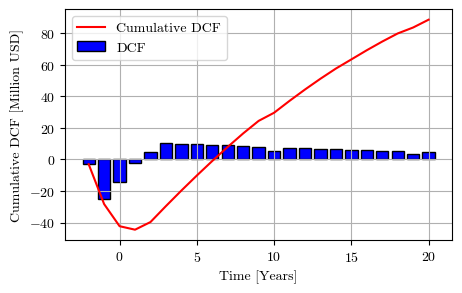

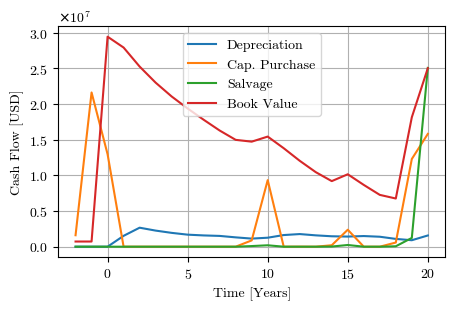

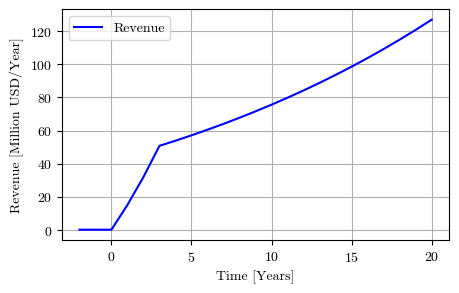

In [11]:
# -----------------------------------------------------------------------
# Pretty plot parameters
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": "cmr10",
    "axes.formatter.use_mathtext": True})

# Dicounted cash flow diagram
plt.bar(t,TOT_CF*1e-6,color='b',edgecolor='k',label='DCF')
plt.plot(t,CDCF*1e-6,color='r',label='Cumulative DCF')
plt.xlabel('Time [Years]')
plt.ylabel('Cumulative DCF [Million USD]')
plt.grid()
plt.legend()
plt.show()

# Depreciation, capital purchases, salvage, book value
# (Capital purchases are shown as positive to plot on the same axis,
#  they are negative in the calculation)
plt.plot(t,DEP,label='Depreciation')
plt.plot(t,CAP_CF,label='Cap. Purchase')
plt.plot(t,SAL,label='Salvage')
plt.plot(t,BOOK_VAL,label='Book Value')
plt.xlabel('Time [Years]')
plt.ylabel('Cash Flow [USD]')
plt.grid()
plt.legend()
plt.show()

# Revenue plot
plt.plot(t,REV*1e-6,color='b',label='Revenue')
plt.xlabel('Time [Years]')
plt.ylabel('Revenue [Million USD/Year]')
plt.grid()
plt.legend()
plt.show()
# -----------------------------------------------------------------------

# Export to Excel

In [13]:
# -----------------------------------------------------------------------
# Years as string vector
yr = list(map(str,np.arange(-const_time[0]+1,N+1)))

# Row names for dataframes
cap_names = pd.concat([prop['Unit ID'],equip['Unit ID'],
                       piping['Unit ID'],controls['Unit ID']]).to_numpy()
cap_names = pd.DataFrame(cap_names,columns=['Year:'])
rev_names = pd.DataFrame(sales['Unit ID'].to_numpy(), columns=['Year:'])
safety_names = pd.DataFrame(safety['Unit ID'].to_numpy(), columns=['Year:'])

rev_names.loc[len(rev_names)] = 'Total'

FCOP_names = pd.DataFrame(['Fixed Labor','Maintenance','Property Tax',
                           'Permits/Regulations','Marketing','Total'],
                            columns=['Year:'])
VCOP_names = pd.DataFrame(['Variable Labor','Utilities','Raw Materials',
                           'Total'],columns=['Year:'])
tax_names = pd.DataFrame(['Property Tax','State Tax','Federal Tax','EBIT',
                          'Total'],columns=['Year:'])
CF_sum_names = pd.DataFrame(['FCOP','VCOP','Revenue','Taxes Paid',
                             'Loans Paid','Total Cash Flow',
                             'Discounted Cash Flow (DCF)',
                             'Cumulative DCF'],columns=['Year:'])

# Generate dataframes for exporting
capital_CF = np.round(np.vstack([prop_CF,eq_CF,piping_CF,controls_CF]))
salvage_CF = np.round(np.vstack([prop_sal_CF,eq_sal_CF,piping_sal_CF,
                                 controls_sal_CF]))
dep_CF = np.round(np.vstack([prop_dep,eq_dep,piping_dep,controls_dep]))
book_val = np.round(np.vstack([prop_book_val,eq_book_val,
                               piping_book_val,controls_book_val]))
prop_tax = np.round(property_tax*np.ones(np.size(t)))

rev = pd.DataFrame(np.vstack([rev_CF,REV]),columns=yr)
cap = pd.DataFrame(np.round(capital_CF),columns=yr)
sal = pd.DataFrame(np.round(salvage_CF),columns=yr)
dep = pd.DataFrame(np.round(dep_CF),columns=yr)
bkv = pd.DataFrame(np.round(book_val),columns=yr)
saf = pd.DataFrame(np.round(safety_CF),columns=yr)

FCOP_tab = np.vstack([fix_labor_CF,OM_CF,prop_tax,sum_safety_CF,MKT,FCOP])
FCOP_df = pd.DataFrame(FCOP_tab,columns=yr)

VCOP_tab = np.round(np.vstack([var_labor_CF,util_CF,raw_mat_CF,VCOP]))
VCOP_df = pd.DataFrame(VCOP_tab,columns=yr)

tax_tab = np.vstack([prop_tax,state_tax,fed_tax,GROSS_P,TAX_CF+prop_tax])
tax_df = pd.DataFrame(tax_tab,columns=yr)

CF_sum_tab = np.vstack([FCOP,VCOP,REV,TAX_CF,
                        yearly_pmt['Payment [USD]'].to_numpy()[1:].T,
                        TOT_CF*(1+MARR[0])**t,TOT_CF,CDCF])
CF_sum_df = pd.DataFrame(CF_sum_tab,columns=yr)

# -----------------------------------------------------------------------
# Write tables to Excel
with pd.ExcelWriter("PVChemix_Financial_Statement.xlsx") as writer:
    profit_summary.to_excel(writer,sheet_name='Profit Indicators',index=False)
    pd.concat([CF_sum_names,CF_sum_df],axis=1).to_excel(writer,
                            sheet_name='Cash Flow Summary',index=False)
    financing.to_excel(writer,sheet_name='Financing Rates',index=False)
    equip.to_excel(writer,sheet_name='Equipment Summary',index=False) 
    prop.to_excel(writer,sheet_name='Property Summary',index=False) 
    piping.to_excel(writer,sheet_name='Piping Summary',index=False)
    controls.to_excel(writer,sheet_name='Controls Summary',index=False)
    raw_mat.to_excel(writer,sheet_name='Raw Materials Summary',index=False)
    piping.to_excel(writer,sheet_name='Piping Summary',index=False)
    sales.to_excel(writer,sheet_name='Sales Summary',index=False)
    labor.to_excel(writer,sheet_name='Labor Costs',index=False)
    utilities.to_excel(writer,sheet_name='Utilities Summary',index=False)
    safety.to_excel(writer,sheet_name=
                    'Safety + Regulations Summary',index=False)

    
    pd.concat([cap_names,cap],axis=1).to_excel(writer,sheet_name=
                                               'Capital Purchase Costs',index=False)
    pd.concat([safety_names,saf],axis=1).to_excel(writer,sheet_name=
                                                  'Cost of Compliance',index=False)
    pd.concat([rev_names,rev],axis=1).to_excel(writer,sheet_name=
                                               'Revenue Cash Flows',index=False)
    pd.concat([cap_names,sal],axis=1).to_excel(writer,sheet_name=
                                               'Salvage Cash Flows',index=False)
    pd.concat([cap_names,dep],axis=1).to_excel(writer,sheet_name=
                                               'Depreciation',index=False)
    yearly_pmt.to_excel(writer,sheet_name='Annual Loan Payments',index=False)
    pd.concat([cap_names,bkv],axis=1).to_excel(writer,sheet_name=
                                               'Book Value of Capital',index=False)
    pd.concat([tax_names,tax_df],axis=1).to_excel(writer,sheet_name=
                                                  'Tax Summary',index=False)
    pd.concat([FCOP_names,FCOP_df],axis=1).to_excel(writer,sheet_name=
                                                    'FCOP Summary',index=False)
    pd.concat([VCOP_names,VCOP_df],axis=1).to_excel(writer,sheet_name=
                                                    'VCOP Summary',index=False)


# Sensitivity Analysis (Monte Carlo)
To better estimate the risk associated with the plant's construction, a
sensitivity analysis must be performed. To forecast likely outcomes, a
Monte-Carlo analysis will be used, which assigns each input variable a
probability distribution. The resulting distribution of the NPV can be
approximated by repeatably sampling the input distributions. This shifts
the determining the uncertainty in the NPV to determining the
uncertainty of the input data, which is generally simpler.

The most important step in Monte Carlo analysis is selection of the
input distributions. To simplify calculations, only two distributions
will be used. The normal distribution will be used for symmetric data
such as product sales prices or raw material costs. The Gumbel
distribution will be used for skewed data such as capital costs. The
density function, $p(x)$, of a normal random variable, $X$, is,
$$\ p(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}\exp{\left(-\frac{1}{2}\left[\frac{x-\mu}{\sigma}\right]^2\right)},$$
where $\mu$ is the mean (equal to the mode for a normal distribution)
and $\sigma$ is the standard deviation. Likewise, the Gumbel
distribution is given by,
$$\ p(x;\mu,\sigma) = \frac{\pi}{\sigma\sqrt{6}}\exp{\left(-\frac{\pi}{\sqrt{6}}\left[\frac{x-\mu}{\sigma}\right]-\exp{\left(-\frac{\pi}{\sqrt{6}}\left[\frac{x-\mu}{\sigma}\right]\right)}\right)},$$
where $\mu$ is the mode and $\sigma$ is the standard deviation. To
capture the central tendency of the data, the input values calculated
from the 'base' cases in the previous section will be used as the most
frequent value (mode) of the distributions. The spread of the data is
characterized by the standard deviation. For a normal distribution,
about 95% of the distribution's mass lies within $\mu\pm2\sigma$, thus,
$2\sigma/\mu$ approximately represents the max fractional deviation from
the mean. For example, if the sales price of a product is $\mu\pm30\%$,
then the standard deviation can be approximated as,
$$\ 2\sigma = 0.30\mu.$$ The standard deviation of Gumbel distribution
can be approximated in a similar way since the lower tail of the
distribution follows a normal distribution while the upper tail follows
an exponential distribution. This means that 95% of the data lies within
$[\mu-2\sigma,\mu+4\sigma]$, i.e. the upper tail has twice the variation
as the lower tail, which is a reasonable assumption for capital costs.


# Random Walk Model (Brownian Motion)
Real assets can be approximated by continuous Brownian motion.
Mathematically, a cash flow, $S$, is modeled by a stochastic
differential equation, $$\ dS = \mu Sdt + \sigma SdW,$$ where $\mu$ is
the mean interest rate, $\sigma$ is the volatility of the interest rate,
and $W$ is a Wiener process. This translates to a random walk in
discrete time. The price of a cash flow, $S_t$, at time, $t$, can be
modeled by,
$$\ \ln{\left(S_{t}\right)} = \ln{\left(S_{t-\Delta t}\right)} + \ln{\left(1+\mu \Delta t +\sqrt{\Delta t}\sigma Z\right)},$$
where $Z$ is a standard Gaussian random variable and $\Delta t$ is taken
to be small. In a Monte Carlo simulation, multiple paths are simulated
with a monthly time step while the cash flow is sampled annually. An
example ensemble of paths is shown for a unit asset compounded at the
MARR rate under Brownian motion.

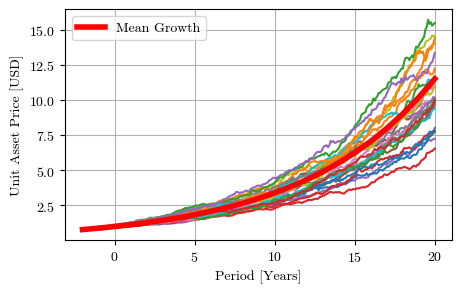

In [19]:
# -----------------------------------------------------------------------
# Plot a sample of Brownian paths compounded at the MARR
num_samples = 25
w12, w, z = get_brownian_rates(params['MARR'],num_samples,N,const_time)

fig, ax = plt.subplots()
plt.plot(z,w)
plt.plot(t,(1+MARR[0])**t,linewidth=4,color='r',label='Mean Growth')
plt.xlabel('Period [Years]')
plt.ylabel('Unit Asset Price [USD]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('asset_Brownian_Motion.png',dpi=600,bbox_inches='tight')


As time moves forward, the Brownian paths diverge from the mean path.
This is reasonable since the model uncertainty accumulates over time. In
other words, information diffuses over time and the model accounts for
the large uncertainties in the price forecasts.

# Run Monte Carlo Simulation

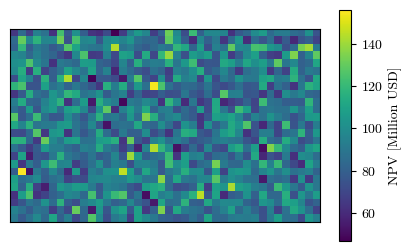

In [21]:
# Number of samples to run for Monte Carlo analysis
num_samples=1000

# Run Monte Carlo trials
NPV = get_MC_analysis(num_samples,input_lists,params)

# Visualize NPV results as a heat map
plt.imshow(np.reshape(NPV*1e-6,(25,-1)))
plt.xticks([])
plt.yticks([])
plt.colorbar(label='NPV [Million USD]')
plt.show()

# Plot Monte Carlo Results

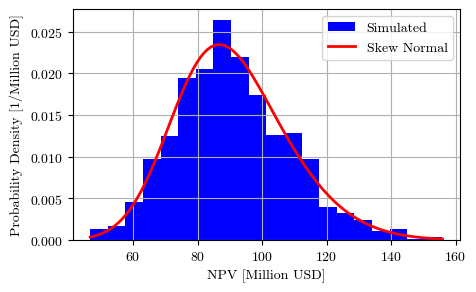

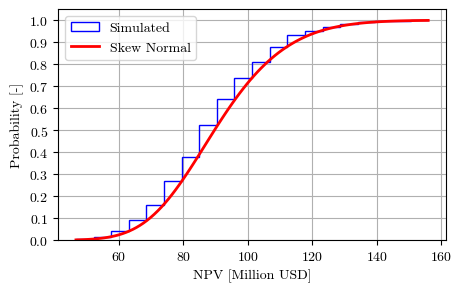

In [23]:
# Convert NPV to million dollar units
dat = NPV*1e-6

# Fit a continuous distribution to the data, try Gumbel
#pg = stats.gumbel_r.fit(dat)
pn = stats.skewnorm.fit(dat)

# Plot PDF/CDF over min/max range
x = np.linspace(np.min(dat),np.max(dat),100)
# PDF - Gumbel
#PDFG = stats.gumbel_r.pdf(x,loc=pg[0],scale=pg[1])
# CFD - Gumbel
#CDFG = stats.gumbel_r.cdf(x,loc=pg[0],scale=pg[1])

# PDF - Normal
PDFN = stats.skewnorm.pdf(x,pn[0],loc=pn[1],scale=pn[2])
# CFD - Normal
CDFN = stats.skewnorm.cdf(x,pn[0],loc=pn[1],scale=pn[2])

# -----------------------------------------------------------------------
# PLot histogram w/ fitted PDF
fig, ax = plt.subplots()
plt.hist(dat,bins='rice',density=True,color='b',label='Simulated')
#plt.plot(x,PDFG,color='green',linewidth=2,label='Gumbel')
plt.plot(x,PDFN,color='r',linewidth=2,label='Skew Normal')
plt.xlabel('NPV [Million USD]')
plt.ylabel('Probability Density [1/Million USD]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_4100_NPV_PDF_Monte_Carlo.png',
            dpi=600,bbox_inches='tight')

def fix_hist_step_vertical_line_at_end(ax):
    axpolygons = [poly for poly in ax.get_children() 
                  if isinstance(poly, mlp.patches.Polygon)]
    for poly in axpolygons:
        poly.set_xy(poly.get_xy()[:-1])
        
# -----------------------------------------------------------------------
# PLot cumulative histogram w/ fitted CDF
fig, ax = plt.subplots()
plt.hist(dat,bins='rice',density=True,color='b',cumulative=True,
         histtype='step',label='Simulated')
fix_hist_step_vertical_line_at_end(ax)
#plt.plot(x,CDFG,color='green',linewidth=2,label='Gumbel')
plt.plot(x,CDFN,color='r',linewidth=2,label='Skew Normal')
plt.xlabel('NPV [Million USD]')
plt.ylabel('Probability [-]')
plt.legend()
plt.yticks(np.linspace(0,1,11))
plt.grid()
plt.show()
fig.savefig('CHEN_4100_NPV_CDF_Monte_Carlo.png',
            dpi=600,bbox_inches='tight')


In [27]:
#var = MC_PIPING
#plt.hist(var,bins='rice',density=True,color='b',label='Simulated')
#plt.xlabel('Variable Value')
#plt.ylabel('Frequency')
#plt.grid()
#plt.show()

#a = np.min(var)/np.mean(var)
#b = np.max(var)/np.mean(var)
#print("Mean: %0.2f" % np.mean(var)) 
#print("Min/Mean: %0.2f" % a)
#print("Max/Mean: %0.2f" % b)

# Sensitivity Analysis Results

Under the model assumptions, the investment has a near-zero probability
of a negative NPV, which means that the investment is almost guaranteed
to generate positive returns. Even under large variations like the
$MARR$ being allowed to deviate $\pm 75\%$ from the base value and the
capital costs ranging about $-40\%/+100\%$ from the base value. Thus,
the investment now becomes a matter of how much profit margins the
investors are willing to accept.

An important note is that the analysis assumes that all input variables
are independently distributed. This is not strictly valid, but is a good
approximation for most inputs. A more detailed analysis should identify
strongly correlated variables and include their covariances into a joint
probability distribution.